# <img style="float: left; padding-right: 20px; width: 200px" src="https://raw.githubusercontent.com/raxlab/imt2200-data/main/media/logo.jpg">  IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Semestre 2025-S2**<br>
**Profesor:** Rodrigo A. Carrasco <br>

# <h1><center>Tarea 03: Exploración de datos </center></h1>

**Fecha de Entrega:** 28 de octubre de 2025, a las 23:59.

**Fecha de publicación**: 14 de octubre de 2025.

**Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en el módulo de Tarea 03 habilitado en Canvas.

## Instrucciones

- Esta Tarea debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
- La Tarea debe ser desarrollada en lenguaje de programación Python y la entrega en formato Jupyter Notebook.
- El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados a los correctores, y siguiendo buenas prácticas de programación. La presentación y claridad del notebook y código forman parte de la evaluación de la tarea.
- Notebook **autocontenible** que:
   - Ejecute sin errores todas las celdas.
  - Contenga tanto el código como los comentarios y explicaciones necesarias.
  - Incluya visualizaciones claras y correctamente etiquetadas.
- No se aceptarán notebooks con celdas rotas o que dependan de rutas externas no indicadas en la tarea.

- Deben hacer sus consultas y comentarios sobre la Tarea a través del canal de Tareas en el Foro del curso en Canvas.

---

## 1. Objetivos

- Aplicar los conceptos iniciales de manejo de datos y análisis exploratorio vistos en clases.
- Practicar la lectura, limpieza y manipulación de datos en Python.
- Desarrollar habilidades para visualizar y describir patrones y tendencias en conjuntos de datos reales.
- Fomentar la capacidad de comunicar resultados de forma clara y fundamentada.

### 1.1 Objetivo educacional

Esta Tarea tiene como objetivo que los estudiantes desarrollen la capacidad de manejar algunas de las librerías centrales para el desarrollo de Ciencia de Datos, con foco en la lectura y exploración de datos. 

Para los ejercicios a continuación, usted deberá leer, inspeccionar, manipular y graficar conjuntos de datos en distintos formatos, de manera de responder las preguntas de cada parte de la Tarea.

### 1.2 Pregunta de ciencia de datos

En esta tarea vamos a analizar la distribución de vulneribilidad escolar para distintos establecimientos educacionales en Chile, desde enseñanza parvularia hasta enseñanza media. Específicamente, queremos entender cómo se comporta un índice de vulnerabilidad en relación a variables como ruralidad, tipo de dependencia y comuna del establecimiento.

---

## 2. Datos

En este estudio, trabajaremos con los resultados publicados anualmente sobre por la JUNAEB
sobre vulnerabilidad de establecimientos educacionales en todo el territorio nacional. Estos resultados están disponibles en la siguiente página web:

* Índices de Vulnerabilidad (JUNAEB): https://www.junaeb.cl/medicion-la-vulnerabilidad-ivm/

Adicionalmente, para visualizar las variables, utilizaremos los mapas vectoriales que disponibiliza la Biblioteca del Congreso Nacional (BCN):

* Mapoteca BCN: https://www.bcn.cl/siit/mapas_vectoriales/index_html

### 2.1 Descarga de datos y conceptos generales (1 punto)

Acceda a los links entregados y descargue el set de datos del **Índice de Vulnerabilidad Multidimensional de Establecimientos Educacionales** para el año 2025. Este debería ser un documento XLSX con múltiples pestañas, incluyendo entre estas un índice que describe las columnas presentes en la base de datos.
Descargue además los archivos correspondientes a la **División comunal: polígonos de las comunas de Chile**. Este se descarga en formato `.zip` y contiene archivos shapefile para visualizar las comunas del país.

Investigue sobre este índice y responda de manera concisa: 
* ¿En qué consiste el IVM? ¿Qué rango de valores toma y qué significan? 
* ¿Cómo se obtiene el IVM de un establecimiento educacional?



Respuesta:

El Índice de Vulnerabilidad Multidimensional (IVM) es una medida generada a partir de la correlación de variables que representan las dimensiones o factores más relevantes de un concepto de vulnerabilidad no observable, según la trayectoria escolar del estudiante. Calculado anualmente segun cada etapa escolar: Parvularia, primer ciclo basico, segundo ciclo basico y Media. Se obtiene gracias a las encuestas de vulnerabilidad de JUNAEB, un metodo basado en distribuciones de probabilidad mediante ecuaciones en cadena y variables segun la etapa escolar: Para Parvularia y el primer ciclo basico se considera el Analisis Factorial de Segundo Orden (indicando cuales son las dimensiones que mas afectan la vulnerabilidad del estudiante) y para el segundo ciclo y educación Media se considera un promedio ponderado de las variables consideradas en el modelo factorial junto con la variable de Nacionalidad que forma parte del score, pero no de la estructura factorial del instrumento, que además busca predecir los resultados de rendimiento-repitencia y abandono-deserción de los estudiantes.

## 3. Lectura y limpieza de datos (1 punto)

### 3.1 Datos de establecimientos (0.5 puntos)
El archivo descargado contiene información sobre establecimientos de cuatro tipos: Parvularia, Primer Ciclo Básica, Segundo Ciclo Básica y Media.
Cargue los datos de los establecimientos en cuatro DataFrames distintos.

Revise cada uno de sus sets de datos y haga un proceso de limpieza si lo considera necesario (manejo de valores nulos, duplicados, inválidos, transformación de tipos de datos, etc). De haberlos, identifique qué atributos son categóricos y transforme los tipos de columna de acuerdo a su decisión, mostrando todos los posibles valores de cada categoría.

Justifique **todas** sus decisiones, **incluso** si decide no realizar una limpieza o transformación.

Finalmente, responda:

* a. ¿Cuántos establecimientos tiene cada set de datos?
* b. ¿Cuánto espacio en memoria ocupan en total los 4 datasets?
* c. ¿Cuántos estudiantes fueron evaluados en todo el país para cada nivel de enseñanza para el año 2025?


In [71]:
#Posibles librerias a usar

import requests
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import os
import seaborn as sns


In [72]:
path_archivo = os.path.join("data", "IVM_Establecimientos_2025-2.xlsx")

df_parvularia = pd.read_excel(path_archivo, sheet_name="Parvularia")
df_primer = pd.read_excel(path_archivo, sheet_name="1º Ciclo Básico")
df_segundo = pd.read_excel(path_archivo, sheet_name="2º Ciclo Básico")
df_media = pd.read_excel(path_archivo, sheet_name="Media")

df_parvularia.info()
df_primer.info()
df_segundo.info()
df_media.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6163 entries, 0 to 6162
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID_RBD                    6163 non-null   int64  
 1   DV_RBD                    6163 non-null   int64  
 2   DS_NOM_ESTABLE            6163 non-null   object 
 3   DS_TIPO_DEPENDENCIA       6163 non-null   object 
 4   DS_RURALIDAD              6163 non-null   object 
 5   ID_REGION_ESTABLE         6163 non-null   int64  
 6   ID_PROVINCIA_ESTABLE      6163 non-null   int64  
 7   ID_COMUNA_ESTABLE         6163 non-null   int64  
 8   DS_COMUNA_ESTABLE         6163 non-null   object 
 9   N EVALUADO                6163 non-null   int64  
 10  IVM Establecimiento       6163 non-null   float64
 11  IVM Bajo                  6163 non-null   int64  
 12  IVM Medio                 6163 non-null   int64  
 13  IVM Alto                  6163 non-null   int64  
 14  IVM Muy 

In [73]:
df_parvularia["DS_TIPO_DEPENDENCIA"].unique()

array(['Servicio Local de Educación(SLE)', 'Particular Subvencionado',
       'Municipal DAEM', 'Corporación Municipal'], dtype=object)

In [74]:
df_parvularia["DS_RURALIDAD"].unique()

array(['Urbano', 'Rural'], dtype=object)

In [75]:
df_parvularia["DS_COMUNA_ESTABLE"].unique()

array(['Arica', 'Putre', 'Iquique', 'Huara', 'Camiña', 'Colchane', 'Pica',
       'Pozo Almonte', 'Tocopilla', 'María Elena', 'Calama',
       'San Pedro de Atacama', 'Antofagasta', 'Mejillones',
       'Sierra Gorda', 'Taltal', 'Chañaral', 'Diego de Almagro',
       'Copiapó', 'Caldera', 'Tierra Amarilla', 'Vallenar', 'Freirina',
       'Huasco', 'Alto del Carmen', 'La Serena', 'La Higuera', 'Coquimbo',
       'Andacollo', 'Vicuña', 'Paiguano', 'Ovalle', 'Río Hurtado',
       'Monte Patria', 'Combarbalá', 'Punitaqui', 'Illapel', 'Salamanca',
       'Los Vilos', 'Canela', 'La Ligua', 'Petorca', 'Cabildo',
       'Zapallar', 'Papudo', 'Los Andes', 'San Felipe', 'San Esteban',
       'Calle Larga', 'Rinconada', 'Putaendo', 'Santa María', 'Panquehue',
       'Llayllay', 'Catemu', 'Quillota', 'Calera', 'La Cruz', 'Nogales',
       'Hijuelas', 'Limache', 'Concón', 'Olmué', 'Valparaíso',
       'Viña del Mar', 'Quilpué', 'Quintero', 'Puchuncaví',
       'Villa Alemana', 'Casablanca', 'Juan F

In [76]:
df_parvularia["N EVALUADO"].sum()

np.int64(255506)

In [77]:
df_primer["N EVALUADO"].sum()

np.int64(882881)

In [78]:
df_segundo["N EVALUADO"].sum()

np.int64(484540)

In [79]:
df_media["N EVALUADO"].sum()

np.int64(901899)

Respuesta: No se hizo ningun cambio a los dfs, ya que no poseen ningun NaN ni valores categoricos similares.

a) Parvularia: 6163 ; Primer ciclo: 7082 ; Segundo ciclo: 5662 ; Media: 2618 

b) 0.3069 + 0.6636 + 1.2 + 1.0112 = 3.1817 MB

c) Parvularia: 255506 ; Primer ciclo: 882881 ; Segundo ciclo: 484540 ; Media: 901899 

### 3.2 Datos geográficos (0.5 puntos)

Cargue en un GeoDataFrame de GeoPandas la información de los polígonos de cada comuna del país.

Como realizamos en la Tarea pasada, puede transformar el Coordinate Reference System (CRS) a EPSG 4326, para tener la información de los puntos de los polígonos con latitud y longitud.

In [80]:
# Respuesta
geopath = os.path.join("data", "comunas.zip")

geodf = gpd.read_file(geopath)
geodf = geodf.to_crs(epsg=4326)
geodf.head()

,objectid,shape_leng,dis_elec,cir_sena,cod_comuna,codregion,st_area_sh,st_length_,Region,Comuna,Provincia,geometry
0,48,170038.624165,16,8,6204,6,9.685774e+08,206184.271675,Región del Libertador Bernardo O'Higgins,Marchigüe,Cardenal Caro,"POLYGON ((-71.80071 -34.20728, -71.79992 -34.2..."
1,29,125730.104795,15,8,6102,6,4.157446e+08,151911.576827,Región del Libertador Bernardo O'Higgins,Codegua,Cachapoal,"POLYGON ((-70.35293 -33.95263, -70.35243 -33.9..."
2,30,63026.084422,15,8,6103,6,1.448565e+08,76355.326122,Región del Libertador Bernardo O'Higgins,Coinco,Cachapoal,"POLYGON ((-70.90058 -34.23703, -70.90063 -34.2..."
3,31,89840.903562,15,8,6104,6,3.256572e+08,108874.623150,Región del Libertador Bernardo O'Higgins,Coltauco,Cachapoal,"POLYGON ((-71.02492 -34.17053, -71.0232 -34.17..."
4,78,122626.493264,23,11,9121,9,6.990727e+08,156680.410681,Región de La Araucanía,Cholchol,Cautín,"POLYGON ((-72.95898 -38.46877, -72.95797 -38.4..."


## 4. Análisis descriptivo (1.5 puntos)

En esta sección haremos una exploración preliminar de los 4 sets de datos cargados. Para cada una de las siguientes preguntas, sustente su respuesta con al menos un gráfico y su análisis respectivo.

**Recomendación:** puede utilizar el método `subplots()` de `matplotlib.pyplot` para facilitar la visualización de múltiples gráficos a la vez.

### 4.1 Ruralidad (0.8 pts)
* a. ¿Cuál es la cantidad de establecimientos rurales vs urbanos según nivel de enseñanza?
* b. ¿Cómo se distribuye el IVM según nivel de enseñanza y ruralidad?


In [81]:
df_parvularia["DS_RURALIDAD"].value_counts()

DS_RURALIDAD
Urbano    4903
Rural     1260
Name: count, dtype: int64

In [82]:
df_primer["DS_RURALIDAD"].value_counts()

DS_RURALIDAD
Urbano    4128
Rural     2954
Name: count, dtype: int64

In [83]:
df_segundo["DS_RURALIDAD"].value_counts()

DS_RURALIDAD
Urbano    4170
Rural     1492
Name: count, dtype: int64

In [84]:
df_media["DS_RURALIDAD"].value_counts()

DS_RURALIDAD
Urbano    2449
Rural      169
Name: count, dtype: int64

<Axes: xlabel='IVM Establecimiento', ylabel='Count'>

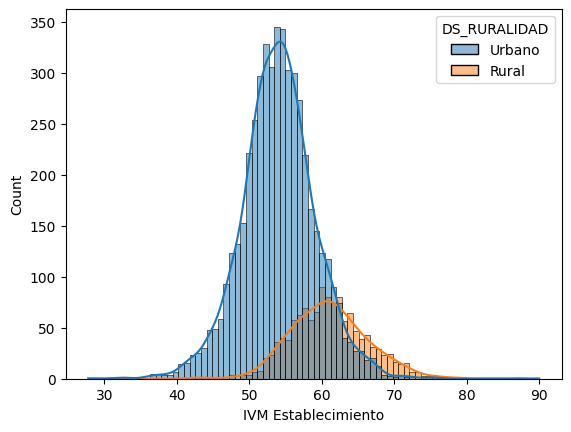

In [85]:
sns.histplot(data=df_parvularia, hue='DS_RURALIDAD', x='IVM Establecimiento', kde=True, bins=80)


<Axes: xlabel='IVM Establecimiento', ylabel='Count'>

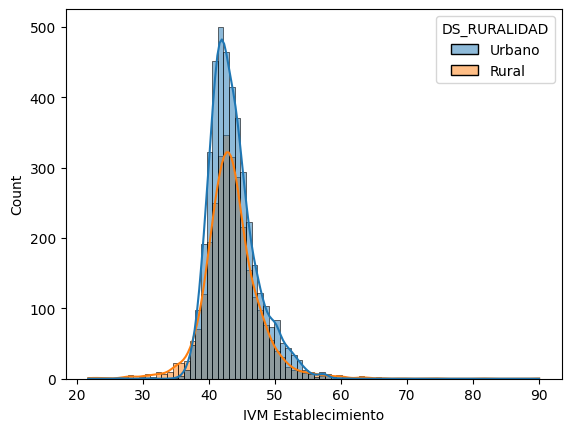

In [86]:
sns.histplot(data=df_primer, hue='DS_RURALIDAD', x='IVM Establecimiento', kde=True, bins=80)


<Axes: xlabel='IVM Establecimiento', ylabel='Count'>

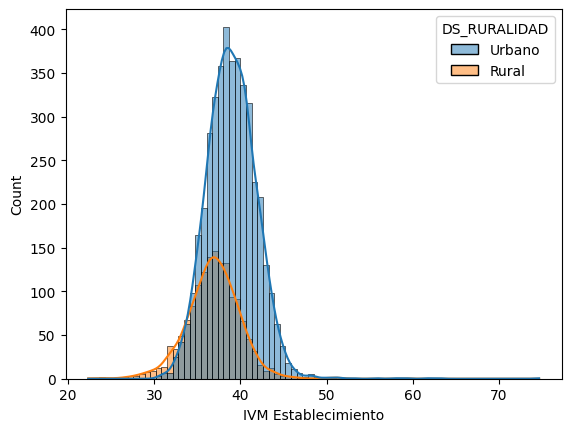

In [87]:
sns.histplot(data=df_segundo, hue='DS_RURALIDAD', x='IVM Establecimiento', kde=True, bins=80)


<Axes: xlabel='IVM Establecimiento', ylabel='Count'>

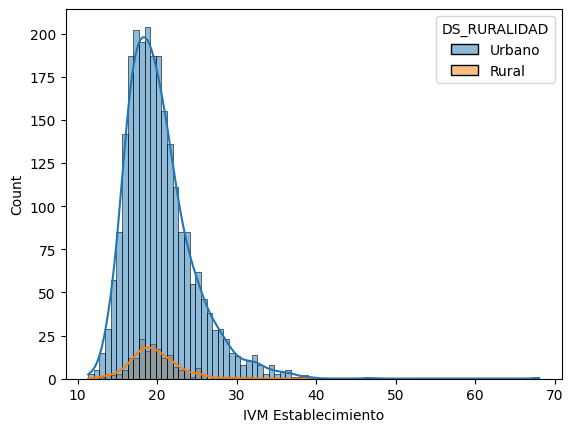

In [88]:
sns.histplot(data=df_media, hue='DS_RURALIDAD', x='IVM Establecimiento', kde=True, bins=80)


Respuesta:

Parvularia:

a) Urbano 4903 y Rural 1260

b) En la educacion parvularia es en el unico nivel de enseñanza donde los establecimientos rurales superan en cantidad a los urbanos en IVMs altos, pero aun asi, los urbanos superan en gran medida en IVMs medios y bajos.



Primer ciclo:

a) Urbano 4128 y Rural 2954

b) En el nivel del primer ciclo, es donde los establecimientos rurales y urbanos estan mas igualados, ya que proporcinalmente siguen la misma linea, simplemente que los urbanos, por cantidad, son superiores.



Segundo ciclo:

a) Urbano 4170 y Rural 1492

b) En el segundo ciclo es cuando empieza a haber mas diferencia, ya que en terminos de cantidad, la diferencia entre rural y urbano se distancian mas, y el pico de IVM de los rurales baja con respecto a el de los urbanos.



Media:

a) Urbano 2449 y Rural 169

b) En el nivel Media, los establecimientos rurales pasan a ser casi despreciables al compararlos con los urbanos, y ambos bajan significativamente su IVM.

### 4.2 Tipo de establecimiento (0.7 pts)

* ¿Cómo es la distribución del IVM promedio de los establecimientos según tipo de dependencia y nivel de enseñanza? 

<Axes: xlabel='IVM Establecimiento', ylabel='Count'>

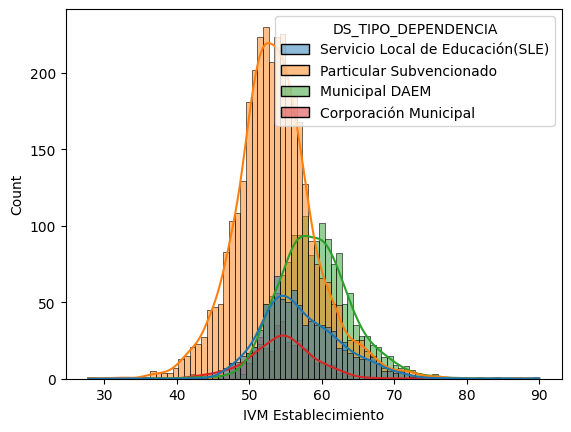

In [89]:
# respuestas
sns.histplot(data=df_parvularia, hue='DS_TIPO_DEPENDENCIA', x='IVM Establecimiento', kde=True, bins=80)


<Axes: xlabel='IVM Establecimiento', ylabel='Count'>

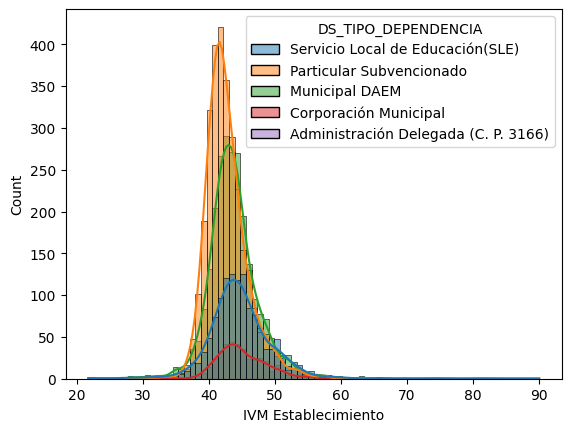

In [90]:
sns.histplot(data=df_primer, hue='DS_TIPO_DEPENDENCIA', x='IVM Establecimiento', kde=True, bins=80)


<Axes: xlabel='IVM Establecimiento', ylabel='Count'>

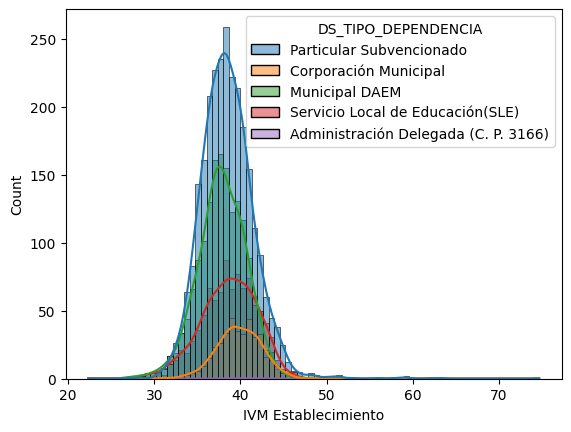

In [91]:
sns.histplot(data=df_segundo, hue='DS_TIPO_DEPENDENCIA', x='IVM Establecimiento', kde=True, bins=80)


<Axes: xlabel='IVM Establecimiento', ylabel='Count'>

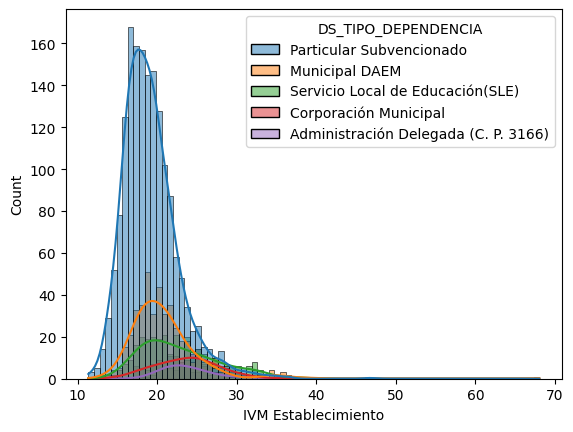

In [92]:
sns.histplot(data=df_media, hue='DS_TIPO_DEPENDENCIA', x='IVM Establecimiento', kde=True, bins=80)


Respuesta y comentarios:

Con los graficos podemos ver que hay un dominio claro en temas de cantidad de los establecimientos particulares subvencionados, pero eso no significa calidad, todo lo contrario, su pico en todos los niveles de enseñanza esta mas bajo que todos los demas. 

Ademas, se puede apreciar que el primer ciclo es muy similar al segundo ciclo, donde proporcionalmente estan muy similares en terminos de la curva del IVM. 

En educacion parvularia, todos suben basyante su IVM en comparacion a los demas niveles, exceptuando los particulares subvencionados, los cuales suben, pero no tanto como los demas. Por otro lado, todos bajan cuando pasan al nivel de enseñanza media.

### 4.3 Pregunta Bono: Dimensiones de vulnerabilidad (1 punto)

Para los niveles de enseñanza Parvularia y Básica Primer ciclo (1-4º), tenemos información sobre distintas dimensiones de que se utilizan para calcular el IVM, como condición socioeconómica familiar y comunal, salud, etc. 

* Para todo Chile, en promedio, ¿cuál es la dimensión con mayor puntaje de IVM para cada uno de estos dos niveles de enseñanza?

In [93]:
# Respuestas
# Crea una lista con todos los promedios
lista_dimensiones = [df_parvularia["IVM Salud"].mean(), df_parvularia["IVM CSE Familiar"].mean(), df_parvularia["IVM Estimulación y Apoyo"].mean(), df_parvularia["IVM Familia"].mean(), df_parvularia["IVM CSE Comunal"].mean(), df_parvularia["IVM Derechos"].mean()]

# Obtiene el promedio max
maximo = max(lista_dimensiones)
for i in range(len(lista_dimensiones)):
    if lista_dimensiones[i] == maximo:
        # Retorna el indice que ocupa la dimension maxima de la lista junto a su valor
        print(i, maximo)
        break

3 70.66708502390739


In [94]:
lista_dimensiones = [df_primer["IVM Salud"].mean(), df_primer["IVM CSE Familia"].mean(), df_primer["IVM Discapacidad"].mean(), df_primer["IVM Familiar"].mean(), df_primer["IVM CSE Comunal"].mean(), df_primer["IVM Educación"].mean(), df_primer["IVM Habitabilidad"].mean()]
maximo = max(lista_dimensiones)
for i in range(len(lista_dimensiones)):
    if lista_dimensiones[i] == maximo:
        print(i, maximo)
        break

1 54.39076164533438


Respuesta y comentarios:
En educacion parvularia es el IVM familiar con un promedio de 70.7 y en educacion del primer ciclo el nivel socioeconomico familiar con un promedio de 54.4

## 5. Agrupación de bases de datos (2 puntos)

El objetivo de esta sección será agrupar los establecimientos según la comuna en la que se encuentran para obtener un resumen general sobre la vulnerabilidad escolar en cada una de ellas. Al finalizar esta sección, tendremos un nuevo DataFrame `agg_comunal` que contenga, al menos, la siguiente información:

* Comuna (nombre y ID)
* Región (ID)
* Cantidad de establecimientos rurales de la comuna
* Cantidad de establecimientos urbanos de la comuna
* Cantidad total de establecimientos de la comuna
* Porcentaje de establecimientos rurales
* IVM Promedio Parvularia de la comuna
* IVM Promedio Básica Primer Ciclo de la comuna
* IVM Promedio Básica Segundo Ciclo de la comuna
* IVM Promedio Media de la comuna
* Objeto geometry de GeoPandas correspondiente al polígono de la comuna respectiva

Armaremos este DataFrame paso a paso.

### 5.1 Cálculo de IVM promedio por comuna (0.8 pts)

Primero, para cada uno sus 4 DataFrames, calcule el promedio de la columna `IVM Establecimiento` según comuna. Almacene este valor en una nueva columna llamada `IVM Promedio {NIVEL DE ENSEÑANZA}` (por ejemplo, para enseñanza parvularia, cree la columna `IVM Promedio Parvularia`).

Junte los 4 resultados que obtuvo en un solo DataFrame `ivm_comunal` que contenga:
* Comuna (nombre y ID)
* Región (ID)
* IVM Promedio Parvularia de la comuna
* IVM Promedio Básica Primer Ciclo de la comuna
* IVM Promedio Básica Segundo Ciclo de la comuna
* IVM Promedio Media de la comuna

Ponga siempre atención al tamaño de sus DataFrames: como estamos agrupando comunalmente, estos siempre debiesen tener una cantidad de filas igual a las comunas de Chile.

In [95]:
# respuestas
# Crea una lista de listas, con el nombre del nivel de ensenanza y su df respectivo (era mas entendible como diccionario, pero funciona, por lo tanto lo dejo como lista)
lista_df = [["Parvularia", df_parvularia.copy()], ["Básica Primer Ciclo", df_primer.copy()], ["Básica Segundo Ciclo", df_segundo.copy()], ["Media", df_media.copy()]]



In [96]:
ivm_comunal = None
for nombre, df in lista_df:
    # por cada df, calcula sus promedios, crea un nuevo df con lo necesario
    promedios = df.groupby(["DS_COMUNA_ESTABLE","ID_COMUNA_ESTABLE", "ID_REGION_ESTABLE"], as_index=False)["IVM Establecimiento"].mean().rename(columns={"DS_COMUNA_ESTABLE": "Comuna (Nombre)","ID_COMUNA_ESTABLE": "Comuna (ID)", "ID_REGION_ESTABLE": "Región (ID)", "IVM Establecimiento": f"IVM Promedio {nombre} de la comuna"})
    promedios.head()
    if ivm_comunal is None:
        ivm_comunal = promedios
    else:
        # va mergeando de a poco cada df
        ivm_comunal = ivm_comunal.merge(promedios, on=["Comuna (Nombre)", "Comuna (ID)", "Región (ID)"], how="outer")
ivm_comunal.head()


,Comuna (Nombre),Comuna (ID),Región (ID),IVM Promedio Parvularia de la comuna,IVM Promedio Básica Primer Ciclo de la comuna,IVM Promedio Básica Segundo Ciclo de la comuna,IVM Promedio Media de la comuna
0,Algarrobo,5602,5,54.409907,42.616750,37.360680,17.935481
1,Alhué,13502,13,57.602370,42.180981,37.536244,20.391982
2,Alto Biobío,8314,8,74.730570,42.929878,34.047618,19.714586
3,Alto Hospicio,1107,1,55.419776,46.599904,41.289463,24.250219
4,Alto del Carmen,3302,3,63.914474,41.493166,35.488871,22.396679


### 5.2 Establecimientos por comuna y ruralidad (0.8 pts)

Ahora contaremos la cantidad de establecimientos por comuna según ruralidad. Como buscamos la cantidad total de establecimientos, consideramos establecimientos de todos los niveles educacionales vistos. Para esto, combine los 4 DataFrames que cargó y genere un nuevo DataFrame `estab_comunal` que contenga:

* Comuna (ID)
* Cantidad de establecimientos rurales
* Cantidad de establecimientos urbanos
* Cantidad total de establecimientos
* Porcentaje de establecimientos rurales (Establecimientos rurales / Total establecimientos * 100)

Tenga en cuenta de que pueden aparecer establecimientos duplicados al combinar estos 4 DataFrames (por ejemplo, establecimientos que imparten múltiples niveles de enseñanza, desde 1º básico hasta 4º medio). Preocúpese de manejar estos casos antes de agrupar sus datos según ruralidad.

In [97]:
estab_comunal = None
for nombre, df in lista_df:
    # Crea por cada df una columna con la cantidad de establecimientos rurales y urbanos
    promedios = df.groupby("ID_COMUNA_ESTABLE", as_index=False).agg(**{f"Cantidad de establecimientos rurales {nombre}": ("DS_RURALIDAD", lambda ruralidad: (ruralidad == "Rural").sum()), f"Cantidad de establecimientos urbanos {nombre}": ("DS_RURALIDAD", lambda ruralidad: (ruralidad == "Urbano").sum())}).rename(columns={"ID_COMUNA_ESTABLE": "Comuna (ID)"})
    promedios.head()
    if estab_comunal is None:
        estab_comunal = promedios
    else:
        estab_comunal = estab_comunal.merge(promedios, on=["Comuna (ID)"], how="outer")


estab_comunal.head()

# Junta los 4 niveles en una sola columna
estab_comunal["Cantidad de establecimientos urbanos"] = estab_comunal["Cantidad de establecimientos urbanos Parvularia"] + estab_comunal["Cantidad de establecimientos urbanos Básica Primer Ciclo"] + estab_comunal["Cantidad de establecimientos urbanos Básica Segundo Ciclo"] + estab_comunal["Cantidad de establecimientos urbanos Media"]
estab_comunal["Cantidad de establecimientos rurales"] = estab_comunal["Cantidad de establecimientos rurales Parvularia"] + estab_comunal["Cantidad de establecimientos rurales Básica Primer Ciclo"] + estab_comunal["Cantidad de establecimientos rurales Básica Segundo Ciclo"] + estab_comunal["Cantidad de establecimientos rurales Media"]

# Se queda solo con las columnas que le interesan
estab_comunal = estab_comunal[["Comuna (ID)", "Cantidad de establecimientos urbanos", "Cantidad de establecimientos rurales"]]

# crea las columnas necesarias
estab_comunal["Cantidad total de establecimientos"] = estab_comunal["Cantidad de establecimientos rurales"] + estab_comunal["Cantidad de establecimientos urbanos"]
estab_comunal["Porcentaje de establecimientos rurales"] = estab_comunal["Cantidad de establecimientos rurales"] / estab_comunal["Cantidad total de establecimientos"] * 100

estab_comunal.head()

,Comuna (ID),Cantidad de establecimientos urbanos,Cantidad de establecimientos rurales,Cantidad total de establecimientos,Porcentaje de establecimientos rurales
0,1101,179.0,10.0,189.0,5.291005
1,1107,98.0,10.0,108.0,9.259259
2,1401,0.0,28.0,28.0,100.000000
3,1402,0.0,12.0,12.0,100.000000
4,1403,0.0,7.0,7.0,100.000000


### 5.3 Unión de bases de datos y polígonos (0.4 pts)

Finalmente, vamos a generar el DataFrame `agg_comunal` con la información de los dos previos DataFrames creados.
Combine la información de las dos secciones anteriores para crear su base de datos unificada. Por último, agregue la columna `geometry` con la información geográfica de cada comuna.

In [98]:
# respuestas
agg_comunal = ivm_comunal.merge(estab_comunal, on=["Comuna (ID)"], how="outer")

# Crea una nueva columna con el mismo nombre para evitar problemas
geodf["Comuna (Nombre)"] = geodf["Comuna"]

# Deja solo las columnas que nos interesan
geodf = geodf[["Comuna (Nombre)", "geometry"]]

# Agrega la geometria
agg_comunal = agg_comunal.merge(geodf, on=["Comuna (Nombre)"], how="outer")

agg_comunal.head()

,Comuna (Nombre),Comuna (ID),Región (ID),IVM Promedio Parvularia de la comuna,IVM Promedio Básica Primer Ciclo de la comuna,IVM Promedio Básica Segundo Ciclo de la comuna,IVM Promedio Media de la comuna,Cantidad de establecimientos urbanos,Cantidad de establecimientos rurales,Cantidad total de establecimientos,Porcentaje de establecimientos rurales,geometry
0,Algarrobo,5602.0,5.0,54.409907,42.616750,37.360680,17.935481,16.0,9.0,25.0,36.000000,"MULTIPOLYGON (((-71.69304 -33.34825, -71.69327..."
1,Alhué,13502.0,13.0,57.602370,42.180981,37.536244,20.391982,4.0,11.0,15.0,73.333333,"POLYGON ((-71.00796 -33.89237, -71.0078 -33.89..."
2,Alto Biobío,8314.0,8.0,74.730570,42.929878,34.047618,19.714586,0.0,19.0,19.0,100.000000,"POLYGON ((-71.32249 -37.5554, -71.32218 -37.55..."
3,Alto Hospicio,1107.0,1.0,55.419776,46.599904,41.289463,24.250219,98.0,10.0,108.0,9.259259,"POLYGON ((-69.89186 -20.06942, -69.89629 -20.1..."
4,Alto del Carmen,3302.0,3.0,63.914474,41.493166,35.488871,22.396679,0.0,21.0,21.0,100.000000,"POLYGON ((-69.68999 -28.60207, -69.68946 -28.6..."


## 6. Análisis de vulnerabilidad por comuna (1.5 puntos)

### 6.1 Mapa de calor (0.8 pts)

Genere mapas de calor de las comunas de Chile según el IVM promedio de los establecimientos educacionales. Realice esto para cada etapa de enseñanza (Parvularia, Básica 1, Básica 2 y Media). Analice y comente sus resultados:
* ¿Cómo se diferencia la vulnerabilidad en distintos sectores del país según nivel de enseñanza?

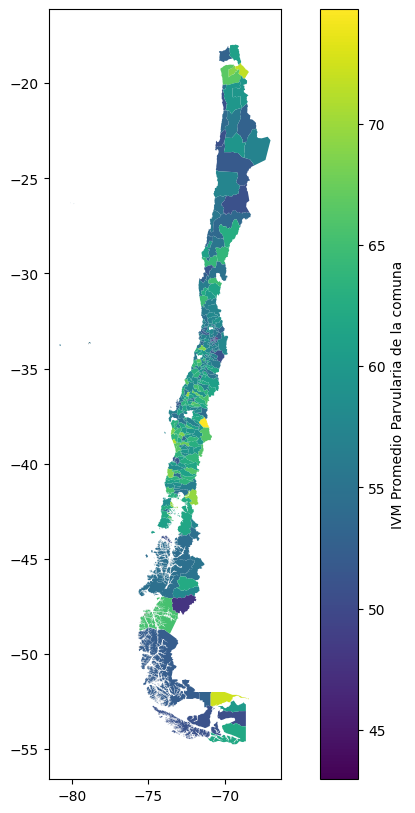

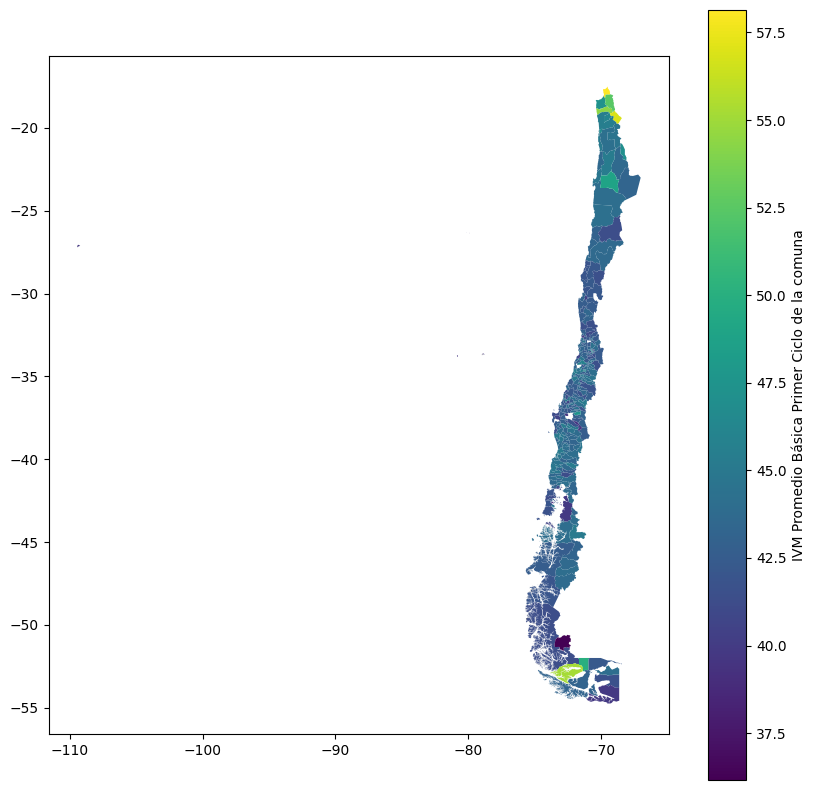

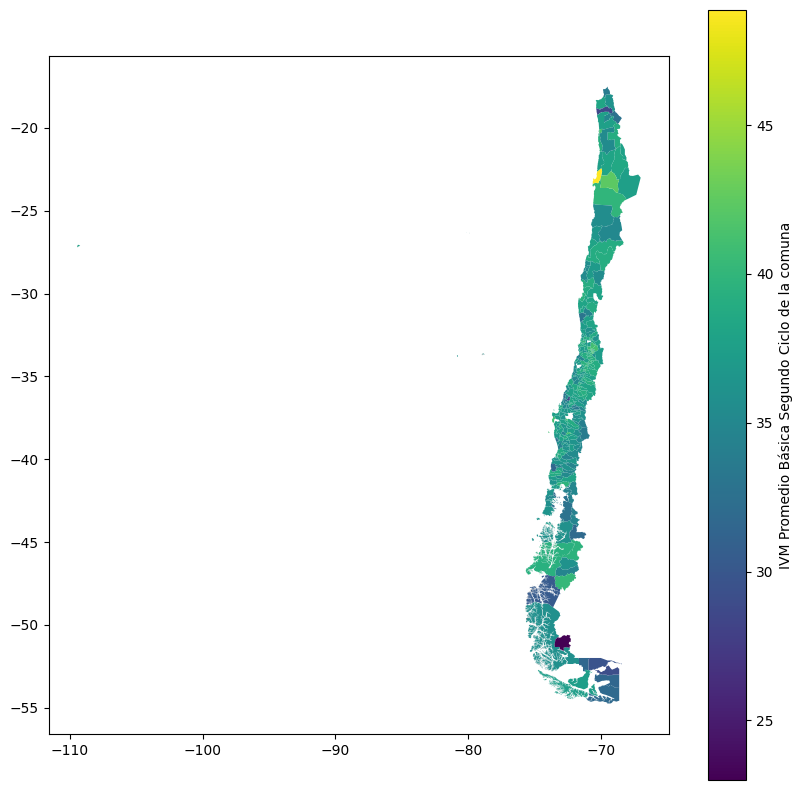

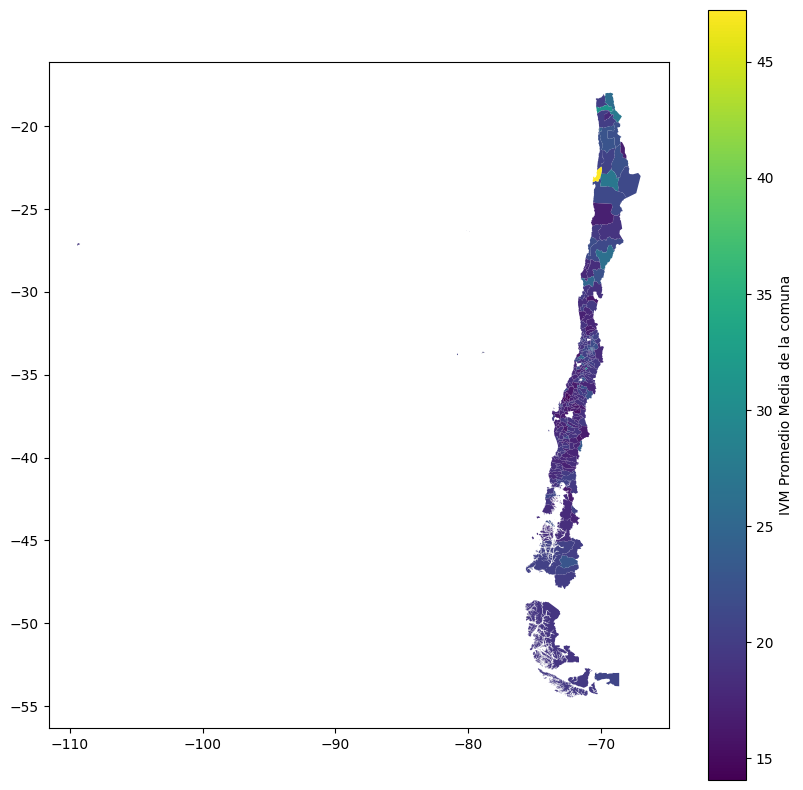

In [99]:
# convierte el df en geodf
agg_comunal = gpd.GeoDataFrame(agg_comunal, geometry="geometry")

# Crea una lista con las columnas que queremos graficar
columnas_a_graficar = ["IVM Promedio Parvularia de la comuna", "IVM Promedio Básica Primer Ciclo de la comuna", "IVM Promedio Básica Segundo Ciclo de la comuna", "IVM Promedio Media de la comuna"]

for columna in columnas_a_graficar:
    # Por cada columna grafica un mapa de las comunas
    fig, ax = plt.subplots(figsize=(10, 10))
    agg_comunal.plot(column=columna, ax=ax, legend=True, legend_kwds={"label": columna})
    plt.show()

Comentarios y análisis:

En Parvularia predomina un IVM alto entre la region del Maule y Los Lagos, con la extraña excepcion que las dos puntas del pais, Arica y Puerto Williams, poseen tambien un alto IVM.

En el primer ciclo, nuevamente tiene el fenomeno de que las dos puntas del pais poseen el mayor IVM, pero en este caso, todo lo demas, esta a un nivel equilibrado de IVM.

En el segundo ciclo la zona centro, Antofagasta y Los Lagos poseen el mayor IVM, y esta vez la zona mas austral del pais baja considerablemente el IVM.

En media se mantiene la mayoria del pais con un IVM similar, con algunas excepciones puntuales en la zona centro, especialmente la comuna de Mejillones, en Antofagasta, que tiene el IVM considerablemente mas alto.

### 6.2 Relación entre ruralidad comunal y vulnerabilidad (0.7 pts)

En la sección **5.2** definimos el **porcentaje de ruralidad** de cada comuna según la cantidad de establecimientos rurales en cada una. Analice y visualice los datos en `agg_comunal` para responder la siguiente pregunta:

* ¿Hay alguna correlación entre el IVM promedio y el porcentaje de ruralidad en las comunas de Chile?

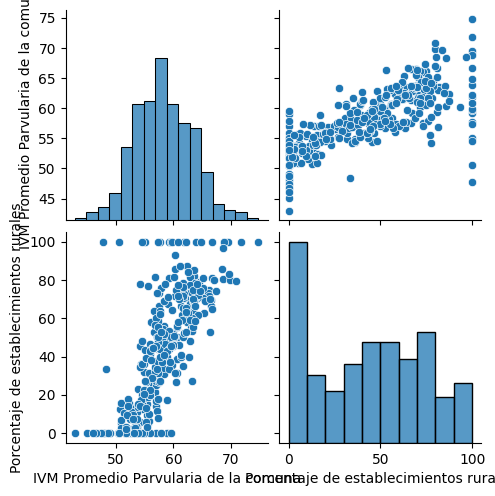

In [100]:
# respuestas
sns.pairplot(agg_comunal[["IVM Promedio Parvularia de la comuna", "Porcentaje de establecimientos rurales"]])

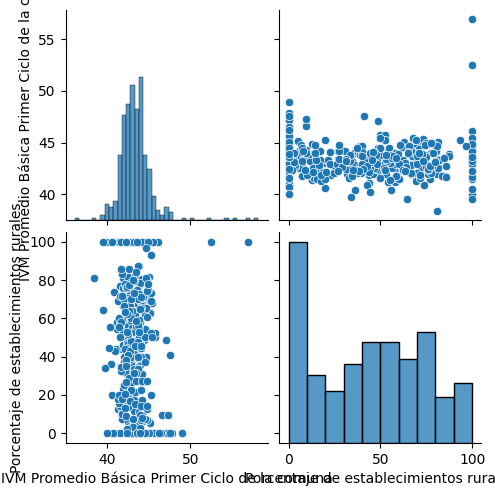

In [101]:
sns.pairplot(agg_comunal[["IVM Promedio Básica Primer Ciclo de la comuna", "Porcentaje de establecimientos rurales"]])

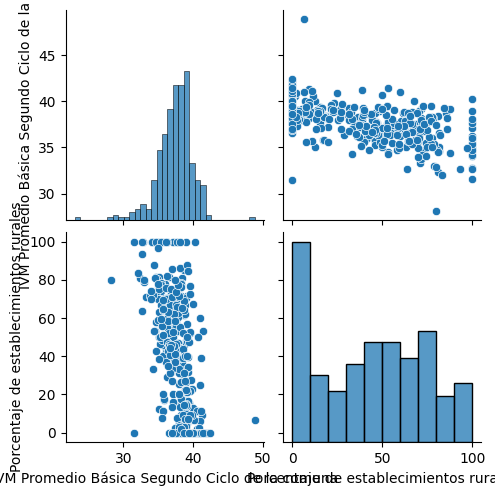

In [102]:
sns.pairplot(agg_comunal[["IVM Promedio Básica Segundo Ciclo de la comuna", "Porcentaje de establecimientos rurales"]])

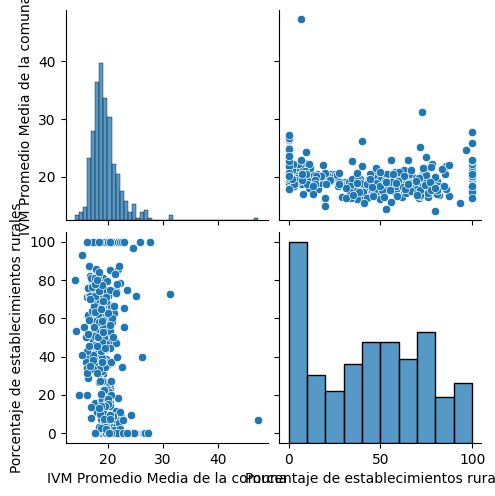

In [103]:
sns.pairplot(agg_comunal[["IVM Promedio Media de la comuna", "Porcentaje de establecimientos rurales"]])

Con los graficos podemos concluir que la unica correlación que hay, es en el nivel Parvulario, donde mientras mas establecimientos rurales tiene la comuna, mas IVM tiene, los demas niveles no parece haber correlación alguna.

## 7 Pregunta Bono (2 punto)

* Proponga una pregunta de análisis que le interese responder con los datos de cualquiera de las bases de datos leídas o generadas durante esta Tarea.
Respóndala de la misma forma que las preguntas anteriores, generando una o varias visualizaciones y analizando sus resultados. Justifique 

**Recomendación**: Trate de proponer una pregunta que justifique el uso de agregación de datos y visualización. En otras palabras, que
no pueda ser respondida directamente sin el uso de gráficos (por ejemplo, *"¿cuál es el establecimiento con mayor IVM?"* puede ser respondida con una búsqueda rápida en el DataFrame).

**Pregunta propuesta:** ¿Como se relaciona el lugar geografico del pais con el porcentaje de establecimientos rurales por cada nivel de enseñanza?

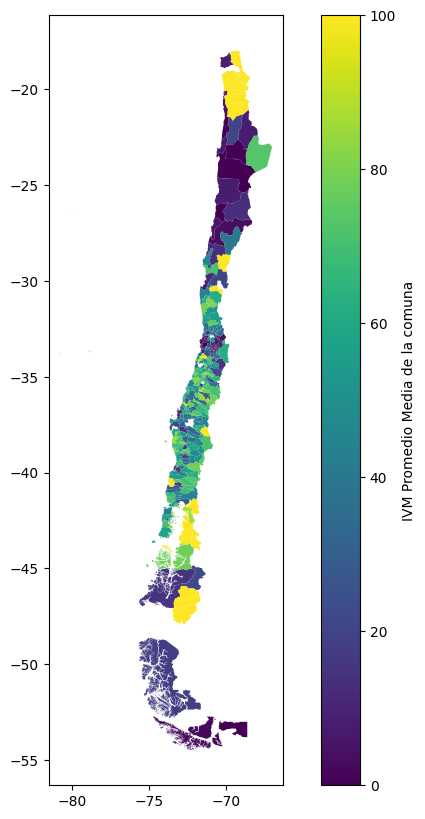

In [104]:
# respuesta

fig, ax = plt.subplots(figsize=(10, 10))
agg_comunal.plot(column="Porcentaje de establecimientos rurales", ax=ax, legend=True, legend_kwds={"label": columna})
plt.show()

Exceptuando Atacama, Antofagasta, Aysén (menos las comunas de Rio Ibañez, Chile Chico y Cochrane) y Magallanes, todas las regiones suelen estar compuestas de la mayoria de establecimientos rurales.